# 9. NTbSchw clustering

Part of the **[Fig. 6 chapter](fig6.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'{rawdir}5kCG.h5ad'`  ·  _other_
- `f'{rawdir}raw/{chrom}.npz'`  ·  _other_
- `f'{group_name}/5kCG_embed.h5ad'`  ·  _embedding h5ad_
- `f'{group_name}/100k3C_embed.h5ad'`  ·  _embedding h5ad_
- `f'{indir}subtype_meta.tsv'`  ·  _metadata_
- `f'{group_name}/{group_name}_mcdist.csv'`  ·  _other_
- `f'{group_name}/{group_name}_3cdist.csv'`  ·  _other_
- `f'{ENTEX_ROOT}/allclist.tsv'`  ·  _sc/pseudobulk mC (allc)_
- `'Mus-Skl/5kCG100k3C_embed.h5ad'`  ·  _embedding h5ad_


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
from glob import glob

import cooler
import anndata
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
from ALLCools.clustering import *
from ALLCools.integration.seurat_class import SeuratIntegration
from ALLCools.plot import *
from sklearn.metrics import pairwise_distances, roc_auc_score
from sklearn.preprocessing import normalize
from sklearn.decomposition import TruncatedSVD

# mpl.use('agg')
mpl.style.use("default")
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = 'none'
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = "Helvetica"

import warnings
warnings.filterwarnings("ignore")


In [2]:
def dump_embedding(adata, name, n_dim=2):
    # put manifold coordinates into adata.obs
    for i in range(n_dim):
        adata.obs[f'{name}_{i}'] = adata.obsm[f'X_{name}'][:, i]
    return adata


In [3]:
indir = f'{ENTEX_ROOT}/'
rawdir = f'{indir}clustering/merged/L2/Glia-Schw/'
anchordir = f'{indir}clustering/tissue/L2/'


In [5]:
group_name = 'NTb-Schw'


In [6]:
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', header=0, index_col=0)
# meta = meta.loc[(meta['Tissue']=='NTb') & (meta['majortype']=='c21')]
meta = meta.loc[meta['subtype'].isin(['c21-b1', 'c21-b3', 'c21-b5'])]
meta

,cluster,subtype,majortype,FinalmCReads,mCHFrac,mCGFrac,CisLongContact,Cis/Trans,Short/Long,Donor,...,L2_5kCG_tsne_0,L2_5kCG_tsne_1,L2_100k3C_tsne_0,L2_100k3C_tsne_1,Tissue_joint_tsne_0,Tissue_joint_tsne_1,Tissue_5kCG_tsne_0,Tissue_5kCG_tsne_1,Tissue_100k3C_tsne_0,Tissue_100k3C_tsne_1
cell,,,,,,,,,,,,,,,,,,,,,
NTb_CHLWU_AR_Plate1-1-I3-B2,c21-c3,c21-b5,c21,1554716,0.007381,0.727240,154397,1.289608,-0.383234,PT-1K2DA,...,-10.514181,12.343171,17.819316,-18.739797,-39.623387,7.912620,-4.414800,-32.522220,-44.545427,2.041701
NTb_CHLWU_AR_Plate1-1-I3-F2,c21-c5,c21-b3,c21,2231495,0.011227,0.729513,267962,1.273850,0.128648,PT-1K2DA,...,-0.184659,32.027971,21.650159,-8.777290,-49.522031,-1.710600,-19.119974,-28.286739,-52.312057,-0.043847
NTb_CHLWU_AR_Plate1-1-I3-G14,c21-c0,c21-b1,c21,2282630,0.008443,0.722778,210707,1.604140,0.243156,PT-1K2DA,...,-13.267741,-9.778685,-7.208920,-1.801101,-12.298031,0.007083,6.028070,-42.515712,-6.078356,2.013117
NTb_CHLWU_AR_Plate1-1-I3-I13,c21-c4,c21-b1,c21,1110369,0.008089,0.717764,136353,1.275352,-0.486772,PT-1K2DA,...,-20.508083,6.391878,-26.419979,-13.019473,-9.125324,-9.040014,0.730829,-29.495481,-2.891170,-5.010457
NTb_CHLWU_AR_Plate1-1-I3-K14,c21-c4,c21-b1,c21,846133,0.009191,0.728464,100089,1.609743,-0.067908,PT-1K2DA,...,-19.100343,6.469448,-18.004086,-6.341208,-9.337982,-9.169121,0.874726,-29.416353,-4.899614,0.896848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NTb_CP2V6_AR_Plate5-6-K20-N11,c21-c0,c21-b1,c21,2368976,0.008810,0.698749,325381,1.676297,-0.161839,PT-1LVAN,...,-19.148612,-20.397205,-16.537869,-17.948196,-10.698324,-3.108803,9.416930,-35.455564,-6.260006,-2.356157
NTb_CP2V6_AR_Plate5-6-K20-N12,c21-c0,c21-b1,c21,3013673,0.008572,0.700292,361911,1.214927,-0.549802,PT-1LVAN,...,-16.578828,-17.603045,-15.281900,-11.591328,-13.656758,0.568107,8.928493,-40.784161,-13.274812,-2.333679
NTb_CP2V6_AR_Plate5-6-K20-O11,c21-c3,c21-b5,c21,4428756,0.020022,0.700295,434073,0.792755,-0.984167,PT-1LVAN,...,-10.691921,-4.998123,13.647474,-18.610188,-37.450745,2.572304,-7.864439,-38.392911,-47.040155,-3.104275


In [10]:
# cellfilter = (mcad.obs['Tissue']=='NTb')
cellfilter = mcad.obs.index.isin(meta.index)
mcad = mcad[cellfilter].copy()
print(cellfilter.sum())

900


In [28]:
mcad.write_h5ad(f'{group_name}/5kCG_embed.h5ad')

In [47]:
mcad = anndata.AnnData(obs=mcad.obs, obsm=mcad.obsm)
mcad

AnnData object with n_obs × n_vars = 900 × 0
    obs: 'FinalmCReads', 'mCHFrac', 'mCGFrac', 'CisLongContact', 'Cis/Trans', 'Donor', 'Tissue', 'celltype', 'ClusterTissue', 'tsne_0', 'tsne_1'
    obsm: '100k3C_pca', 'X_pca', '100k3C_pc10_seuratL2', 'X_tsne', '100k3C_pc10_seuratL2_tsne'

In [48]:
mcad.write_h5ad(f'{group_name}/100k3C_embed.h5ad')


In [7]:
coord_base = 'tsne'
adata_mc = anndata.read_h5ad(f'{group_name}/5kCG_embed.h5ad')[meta.index].copy()
adata_3c = anndata.read_h5ad(f'{group_name}/100k3C_embed.h5ad')[meta.index].copy()
npc_cg, npc_3c = 10, 10
ds = 150/np.sqrt(meta.shape[0])


In [8]:
adata_mc = dump_embedding(adata_mc, coord_base)
adata_3c = dump_embedding(adata_3c, coord_base)


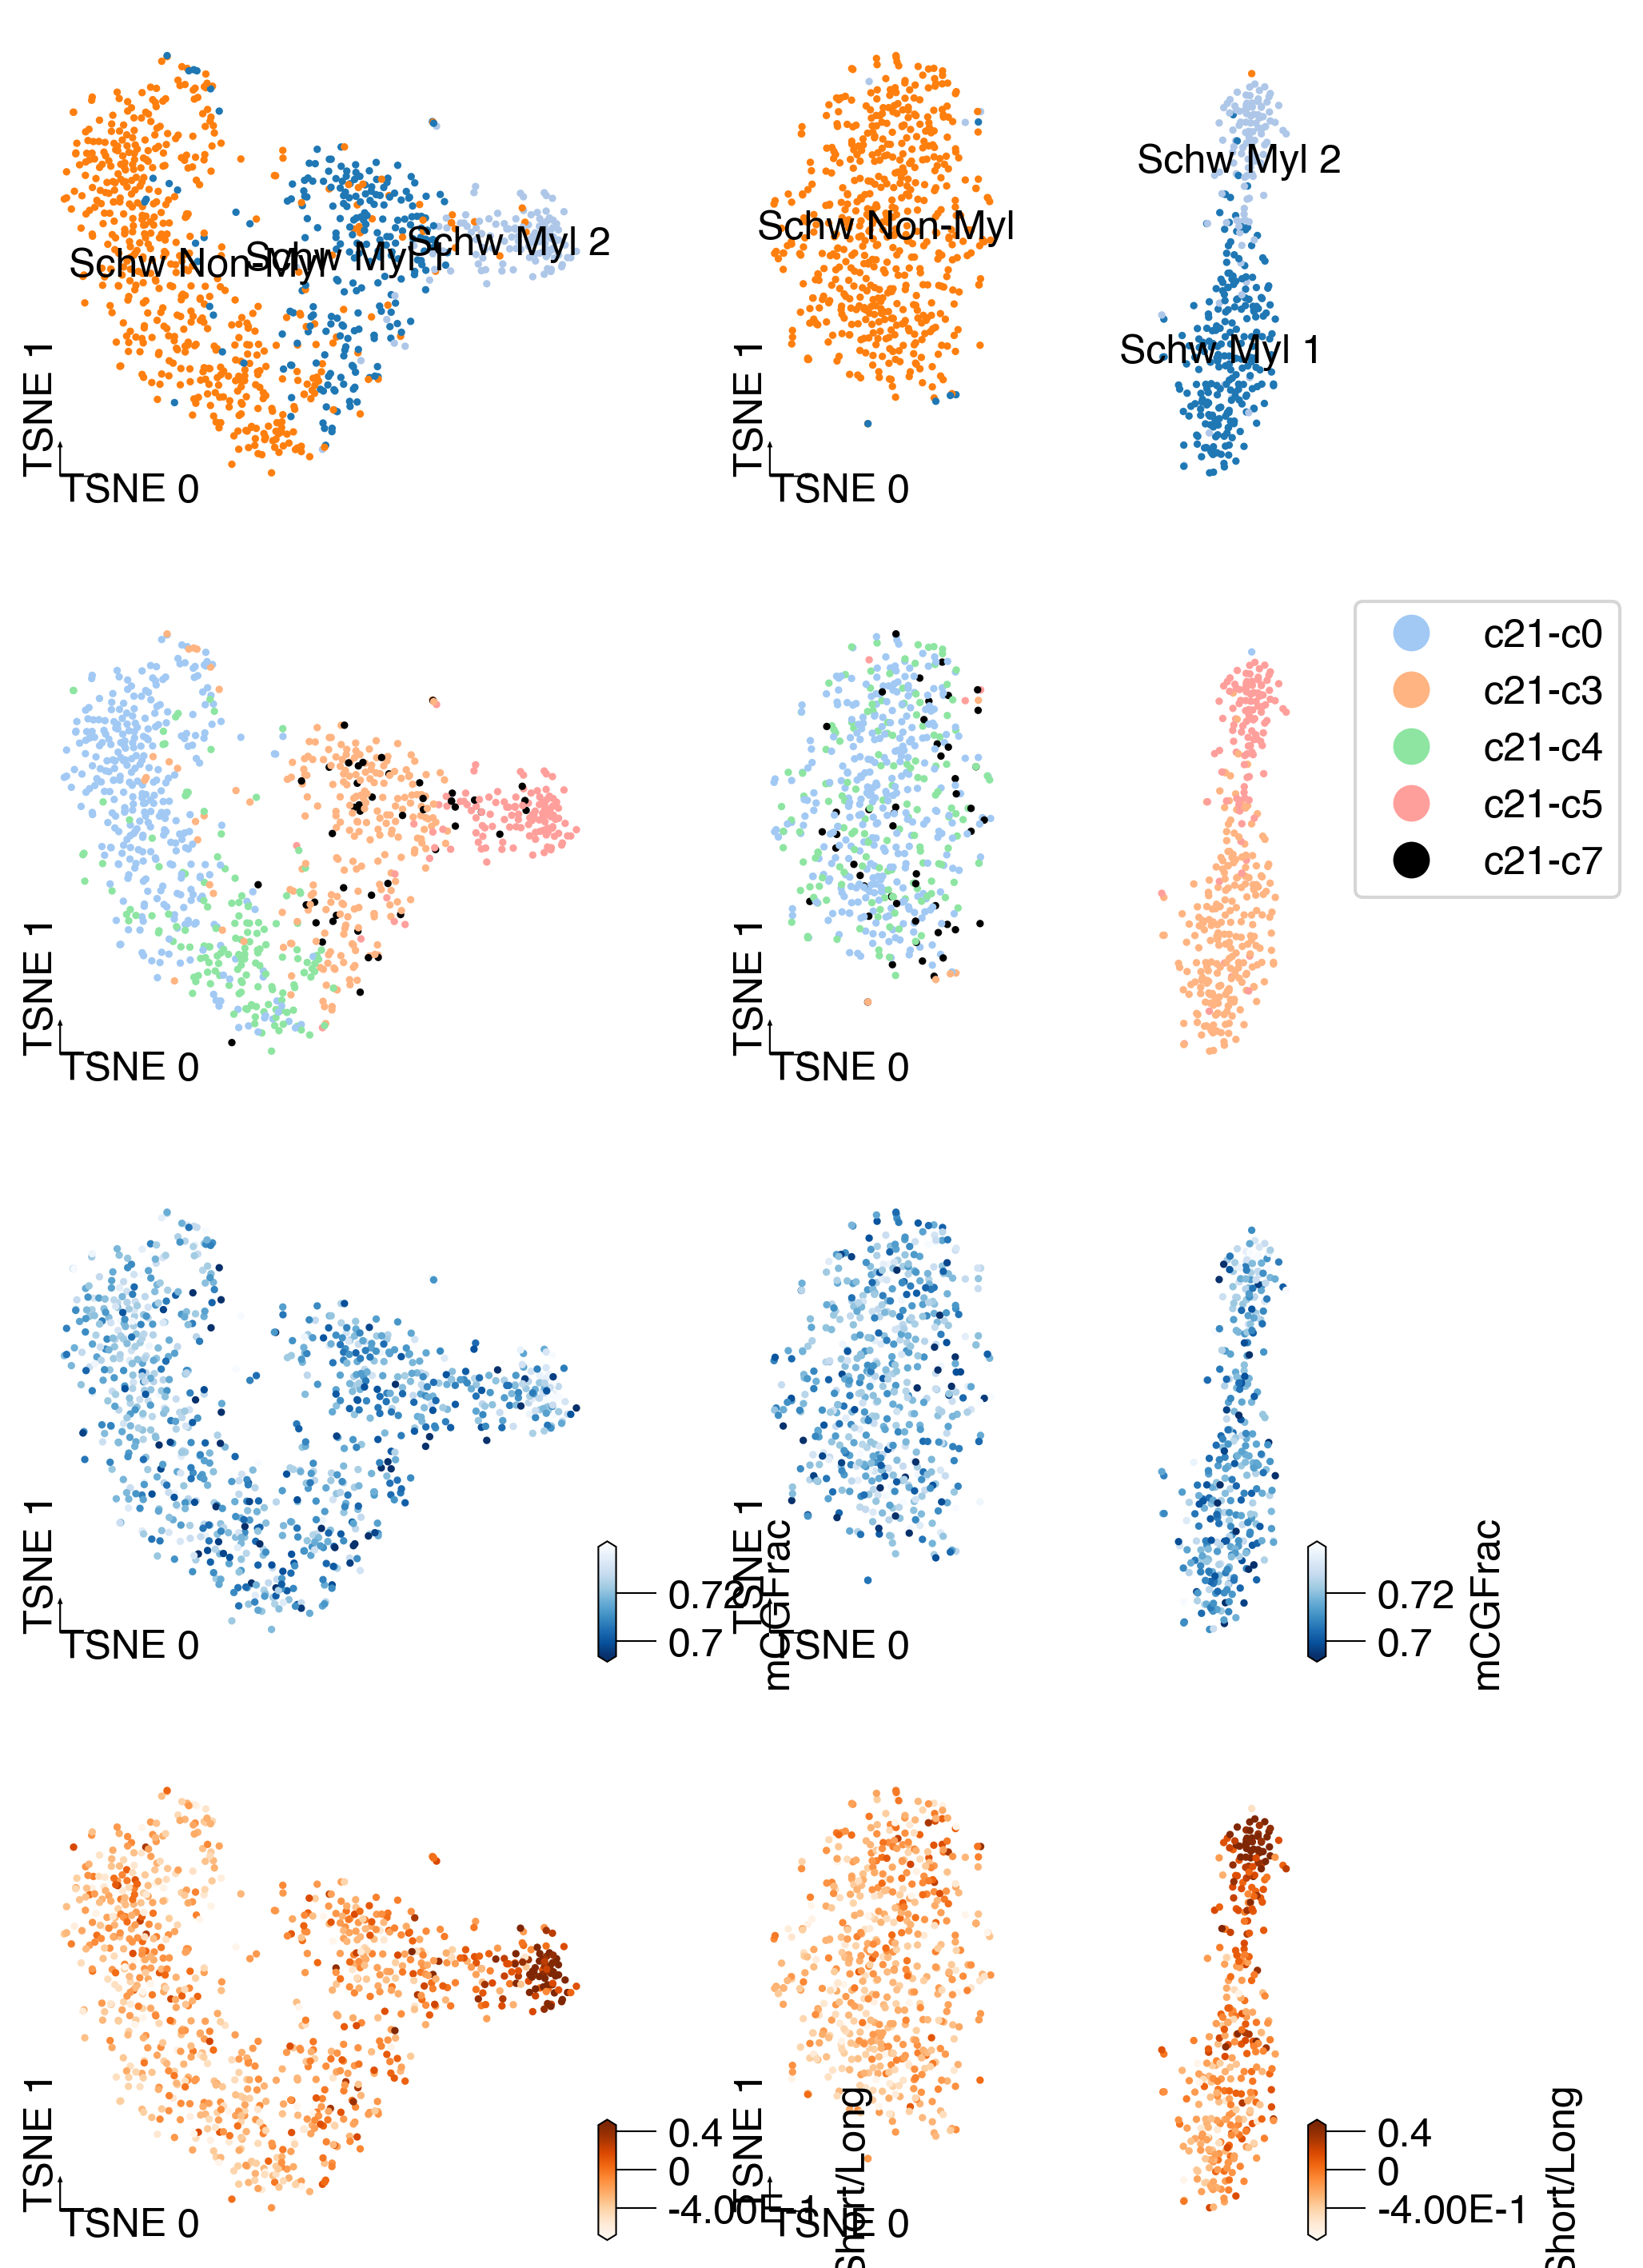

In [54]:

count = meta['subtype'].value_counts()
selc = meta['subtype'].isin(count.index[count>=20])

fig, axes = plt.subplots(4, 2, figsize=(7,12), dpi=300)
for i,adata in enumerate([adata_mc, adata_3c]):
    tmp = adata.obs.loc[selc].copy()
    ax = axes[0,i]
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=meta['L2_annot'],
                            # text_anno=meta['L2_annot'], 
                            s=ds,
                            labelsize=12,
                            max_points=None,
                            palette='tab20',
                            scatter_kws={'rasterized':True},
                            # legend_kws={'ncol':1}, 
                            # show_legend=True
                           )
    leg = np.sort(meta.loc[selc, 'L2_annot'].unique())
    for yy in leg:
        x, y = np.mean(adata.obsm[f'X_{coord_base}'][meta['L2_annot']==yy], axis=0)
        ax.text(x, y, yy, ha='center', va='center', fontsize=12)
    
    ax = axes[1,i]
    leg = np.sort(meta.loc[selc, 'cluster'].unique())
    color_palette = {xx:yy for xx,yy in zip(leg, list(sns.color_palette('pastel', 4))+[(0,0,0)])}
    _ = categorical_scatter(data=tmp,
                            ax=ax,
                            coord_base=coord_base,
                            hue=meta['cluster'],
                            # text_anno=meta['cluster'], 
                            s=ds,
                            labelsize=12,
                            max_points=None,
                            palette=color_palette,
                            scatter_kws={'rasterized':True},
                            legend_kws={'ncol':1}, 
                            show_legend=(i==1)
                           )
    # for yy in leg:
    #     x, y = np.mean(adata.obsm[f'X_{coord_base}'][meta['cluster']==yy], axis=0)
    #     ax.text(x, y, yy, ha='center', va='center', fontsize=12)

    ax = axes[2,i]
    _ = continuous_scatter(data=tmp,
                           ax=ax,
                           coord_base=coord_base,
                           hue=meta['mCGFrac'],
                           s=ds,
                           cmap='Blues_r',
                           labelsize=12,
                           max_points=None,
                           scatter_kws={'rasterized':True},
                          )

#     ax = axes[2,i]
#     _ = continuous_scatter(data=tmp,
#                            ax=ax,
#                            coord_base=coord_base,
#                            hue=meta['mCHFrac'],
#                            s=ds,
#                            labelsize=12,
#                            max_points=None,
#                            scatter_kws={'rasterized':True},
#                           )

    ax = axes[3,i]
    _ = continuous_scatter(data=tmp,
                           ax=ax,
                           coord_base=coord_base,
                           hue=meta['Short/Long'],
                           s=ds,
                           cmap='Oranges',
                           labelsize=12,
                           max_points=None,
                           scatter_kws={'rasterized':True},
                          )

#     ax = axes[4,i]
#     _ = continuous_scatter(data=tmp,
#                            ax=ax,
#                            coord_base=coord_base,
#                            hue=meta['Cis/Trans'],
#                            s=ds,
#                            labelsize=12,
#                            max_points=None,
#                            scatter_kws={'rasterized':True},
#                           )
plt.savefig(f'{group_name}/{group_name}_modality_tsne.pdf', transparent=True)


In [26]:
dist_cg = np.around(dist_cg, decimals=3)
dist_3c = np.around(dist_3c, decimals=3)


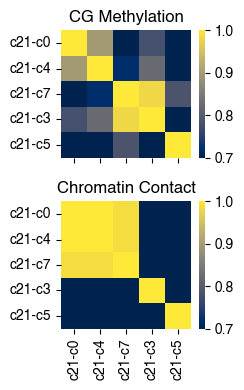

In [33]:
leg_order = pd.Index(['c21-c0', 'c21-c4', 'c21-c7', 'c21-c3', 'c21-c5'])
# dist_cg = pd.DataFrame(np.eye(len(leg_order)), index=leg_order, columns=leg_order)
# dist_3c = pd.DataFrame(np.eye(len(leg_order)), index=leg_order, columns=leg_order)
fig, axes = plt.subplots(2, 1, figsize=(2.5, 4), sharex='all', sharey='all')
for i,dist in enumerate([dist_cg, dist_3c]):
    ax = axes[i]
    sns.heatmap(1-dist.loc[leg_order, leg_order], cmap='cividis', vmin=0.7, vmax=1.0, ax=ax)
    # ax.set_xticks(np.arange(len(leg_order)))
    # ax.set_xticklabels(leg_order, rotation=90)
    # ax.set_yticks(np.arange(len(leg_order)))
    # ax.set_yticklabels(leg_order)
    ax.set_title(['CG Methylation', 'Chromatin Contact'][i])
    
fig.tight_layout()
fig.savefig(f'{group_name}/{group_name}_modality_pc_cluster_confusion.pdf', transparent=True)
